# Backtests DAX 40 — ASRS · Expresso · PDH/PDL

Backtest de trois stratégies intraday sur le DAX 40 (données CSV 2006–2026 + Capital.com).

**Plan du notebook :**
1. Chaque stratégie est d'abord présentée et backtestée **sans filtre**.
2. Une analyse descriptive par stratégie révèle les régimes défavorables.
3. Les filtres sont appliqués comme **conséquences** de cette analyse.
4. Comparaison finale des trois stratégies filtrées.

In [18]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print(f'ROOT = {ROOT}')

ROOT = c:\Users\ali\Desktop\Projet-INFO-2AS2


In [19]:
# ── Données CSV 2006-2026 ────────────────────────────────────────────────────
raw = pd.read_csv(
    ROOT / 'data' / 'dax-5m_bk.csv', sep=';', header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
)
raw['datetime'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], format='%d/%m/%Y %H:%M')
raw = raw.drop(columns=['date', 'time']).set_index('datetime').sort_index()
raw = raw[raw.index >= '2006-01-01']

# ── Données Capital.com (live ~1 an) ─────────────────────────────────────────
live_raw = pd.read_csv(ROOT / 'data' / 'dax_live_5min.csv', index_col=0, parse_dates=True)
live_raw.index = pd.to_datetime(live_raw.index, utc=True).tz_convert('Europe/Berlin').tz_localize(None)
live = live_raw[~live_raw.index.duplicated()].sort_index().between_time('09:00', '17:35')

print(f'CSV  : {len(raw):,} lignes  {raw.index[0].date()} -> {raw.index[-1].date()}')
print(f'Live : {len(live):,} lignes  {live.index[0].date()} -> {live.index[-1].date()}')

CSV  : 998,622 lignes  2006-01-02 -> 2026-04-06
Live : 27,933 lignes  2025-04-07 -> 2026-04-21


In [20]:
def compute_metrics(df, label=''):
    if df.empty:
        return {}
    winners = df[df['pnl'] > 0]
    losers  = df[df['pnl'] < 0]
    gw  = winners['pnl'].sum() if len(winners) else 0
    gl  = abs(losers['pnl'].sum()) if len(losers) else 1e-9
    std = df['pnl'].std()
    cum = df['pnl'].cumsum()
    return {
        'label':         label,
        'n_trades':      len(df),
        'win_rate_%':    round((df['pnl'] > 0).mean() * 100, 1),
        'avg_win':       round(winners['pnl'].mean(), 1) if len(winners) else 0,
        'avg_loss':      round(losers['pnl'].mean(), 1)  if len(losers)  else 0,
        'profit_factor': round(gw / gl, 2),
        'total_pnl':     round(df['pnl'].sum(), 0),
        'sharpe':        round(df['pnl'].mean() / std * np.sqrt(252), 2) if std > 0 else 0,
        'max_dd':        round((cum - cum.cummax()).min(), 0),
    }


def show_equity(df, title, color='#1565C0'):
    fig, ax = plt.subplots(figsize=(13, 4))
    cum = df['pnl'].cumsum()
    ax.fill_between(cum.index, cum.values, 0, where=cum.values >= 0, alpha=0.15, color='green')
    ax.fill_between(cum.index, cum.values, 0, where=cum.values  < 0, alpha=0.15, color='red')
    ax.plot(cum.index, cum.values, color=color, lw=1.8)
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_ylabel('PnL cumulé (pts)')
    ax.grid(True, alpha=0.3)
    m = compute_metrics(df)
    ax.set_title(
        f"{title}  |  N={m['n_trades']:,}  WR={m['win_rate_%']}%  "
        f"PF={m['profit_factor']}  PnL={m['total_pnl']:+,.0f}  MaxDD={m['max_dd']:,.0f}"
    )
    plt.tight_layout()
    plt.show()

---
## 1. ASRS — Advanced School Run Strategy

**Signal** : High/Low de la 4ème bougie 5min (09:15 CET).

**Logique** : Deux ordres stop OCO — buy stop au-dessus du High+buffer, sell stop en-dessous du Low−buffer. Le premier niveau atteint déclenche la position. Stop loss = l'autre niveau d'entrée. Sortie en fin de journée (17:30) si le stop n'est pas touché.

> Backtest **sans filtre** ci-dessous — toutes les journées depuis 2006.

In [21]:
ENTRY_BUFFER_ASRS = 2
EOD_ASRS          = '17:30'

bars_4th = raw[raw.index.strftime('%H:%M') == '09:15'].copy()
bars_4th.index = bars_4th.index.normalize()
print(f'Jours signal ASRS disponibles : {len(bars_4th):,}')


def simulate_day_asrs(day_bars, sig_high, sig_low):
    el = sig_high + ENTRY_BUFFER_ASRS
    es = sig_low  - ENTRY_BUFFER_ASRS
    if day_bars['open'].iloc[0] >= el or day_bars['open'].iloc[0] <= es:
        return None  # gap au-dela du niveau -> fill irrealiste
    direction = entry_price = entry_time = stop = None

    for ts, bar in day_bars.iterrows():
        if direction: break
        bh, bl = bar['high'], bar['low']
        if bh >= el and bl <= es:
            direction, entry_price, stop = ('long', el, es) if bar['open'] >= el else ('short', es, el)
        elif bh >= el:  direction, entry_price, stop = 'long',  el, es
        elif bl <= es:  direction, entry_price, stop = 'short', es, el
        if direction: entry_time = ts

    if not direction:
        return None

    max_adv = max_fav = 0.0
    exit_price = exit_reason = None
    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        bh, bl = bar['high'], bar['low']
        if direction == 'long':
            max_adv = max(max_adv, entry_price - bl)
            max_fav = max(max_fav, bh - entry_price)
            if bl <= stop: exit_price, exit_reason = stop, 'stop'; break
        else:
            max_adv = max(max_adv, bh - entry_price)
            max_fav = max(max_fav, entry_price - bl)
            if bh >= stop: exit_price, exit_reason = stop, 'stop'; break

    if exit_price is None:
        exit_price = day_bars[day_bars.index >= entry_time].iloc[-1]['close']
        exit_reason = 'eod'

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)
    return {
        'direction':    direction,
        'entry_price':  round(entry_price, 2),
        'exit_price':   round(exit_price, 2),
        'stop':         round(stop, 2),
        'pnl':          round(pnl, 2),
        'exit_reason':  exit_reason,
        'max_adverse':  round(max_adv, 2),
        'max_favorable':round(max_fav, 2),
        'sig_range':    round(sig_high - sig_low, 2),
    }


def run_asrs(no_friday=False, range_filter=False, skip_months=False):
    SKIP_M = {1, 7, 8}
    trades = []
    for trade_date in bars_4th.index.unique():
        ts = pd.Timestamp(trade_date)
        if no_friday   and ts.dayofweek == 4:    continue
        if skip_months and ts.month in SKIP_M:   continue
        row = bars_4th.loc[trade_date]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        sig_high, sig_low = row['high'], row['low']
        if range_filter and not (10 <= sig_high - sig_low <= 55): continue
        day_bars = raw.loc[f'{trade_date} 09:20':f'{trade_date} {EOD_ASRS}']
        if len(day_bars) < 2: continue
        r = simulate_day_asrs(day_bars, sig_high, sig_low)
        if r:
            r['trade_date'] = ts
            trades.append(r)
    return pd.DataFrame(trades).set_index('trade_date').sort_index()

Jours signal ASRS disponibles : 5,137


In [22]:
asrs_raw = run_asrs()
m = compute_metrics(asrs_raw, 'ASRS brut (sans filtre)')
print(pd.DataFrame([m]).set_index('label').to_string())

                         n_trades  win_rate_%  avg_win  avg_loss  profit_factor  total_pnl  sharpe  max_dd
label                                                                                                     
ASRS brut (sans filtre)      5136        28.3     55.2     -20.0           1.09     6405.0    0.42 -2638.0


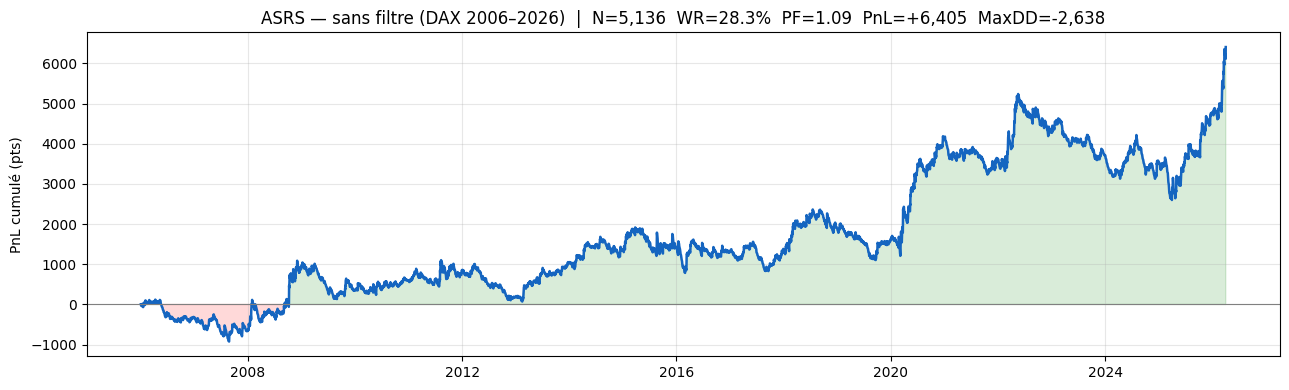

In [23]:
show_equity(asrs_raw, 'ASRS — sans filtre (DAX 2006–2026)', color='#1565C0')

---
## 2. Expresso

**Signal** : High/Low de la bougie pré-ouverture 08:55 CET (se ferme à 09:00).

**Logique** : Même mécanique OCO que l'ASRS, buffer ±17 pts (plus large car signal plus tôt).

> Backtest **sans filtre** ci-dessous.

In [24]:
ENTRY_BUFFER_EXP = 17
EOD_EXP          = '17:30'

bars_exp = raw[raw.index.strftime('%H:%M') == '08:55'].copy()
bars_exp.index = bars_exp.index.normalize()
print(f'Jours signal Expresso disponibles : {len(bars_exp):,}')


def simulate_day_exp(day_bars, sig_high, sig_low):
    el = sig_high + ENTRY_BUFFER_EXP
    es = sig_low  - ENTRY_BUFFER_EXP
    if day_bars['open'].iloc[0] >= el or day_bars['open'].iloc[0] <= es:
        return None  # gap au-dela du niveau -> fill irrealiste
    direction = entry_price = entry_time = stop = None

    for ts, bar in day_bars.iterrows():
        if direction: break
        bh, bl = bar['high'], bar['low']
        if bh >= el and bl <= es:
            direction, entry_price, stop = ('long', el, es) if bar['open'] >= el else ('short', es, el)
        elif bh >= el:  direction, entry_price, stop = 'long',  el, es
        elif bl <= es:  direction, entry_price, stop = 'short', es, el
        if direction: entry_time = ts

    if not direction:
        return None

    max_adv = max_fav = 0.0
    exit_price = exit_reason = None
    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        bh, bl = bar['high'], bar['low']
        if direction == 'long':
            max_adv = max(max_adv, entry_price - bl)
            max_fav = max(max_fav, bh - entry_price)
            if bl <= stop: exit_price, exit_reason = stop, 'stop'; break
        else:
            max_adv = max(max_adv, bh - entry_price)
            max_fav = max(max_fav, entry_price - bl)
            if bh >= stop: exit_price, exit_reason = stop, 'stop'; break

    if exit_price is None:
        exit_price = day_bars[day_bars.index >= entry_time].iloc[-1]['close']
        exit_reason = 'eod'

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)
    return {
        'direction':    direction,
        'entry_price':  round(entry_price, 2),
        'exit_price':   round(exit_price, 2),
        'stop':         round(stop, 2),
        'pnl':          round(pnl, 2),
        'exit_reason':  exit_reason,
        'max_adverse':  round(max_adv, 2),
        'max_favorable':round(max_fav, 2),
        'sig_range':    round(sig_high - sig_low, 2),
    }


def run_expresso(no_friday=False, range_filter=False, skip_months=False):
    SKIP_M = {1, 7, 8}
    trades = []
    for trade_date in bars_exp.index.unique():
        ts = pd.Timestamp(trade_date)
        if no_friday   and ts.dayofweek == 4:   continue
        if skip_months and ts.month in SKIP_M:  continue
        row = bars_exp.loc[trade_date]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        sig_high, sig_low = row['high'], row['low']
        if range_filter and not (10 <= sig_high - sig_low <= 55): continue
        day_bars = raw.loc[f'{trade_date} 09:00':f'{trade_date} {EOD_EXP}']
        if len(day_bars) < 2: continue
        r = simulate_day_exp(day_bars, sig_high, sig_low)
        if r:
            r['trade_date'] = ts
            trades.append(r)
    return pd.DataFrame(trades).set_index('trade_date').sort_index()

Jours signal Expresso disponibles : 5,137


In [25]:
exp_raw = run_expresso()
m = compute_metrics(exp_raw, 'Expresso brut (sans filtre)')
print(pd.DataFrame([m]).set_index('label').to_string())

                             n_trades  win_rate_%  avg_win  avg_loss  profit_factor  total_pnl  sharpe  max_dd
label                                                                                                         
Expresso brut (sans filtre)      4863        45.7     48.7     -37.7           1.09     8772.0    0.49 -1886.0


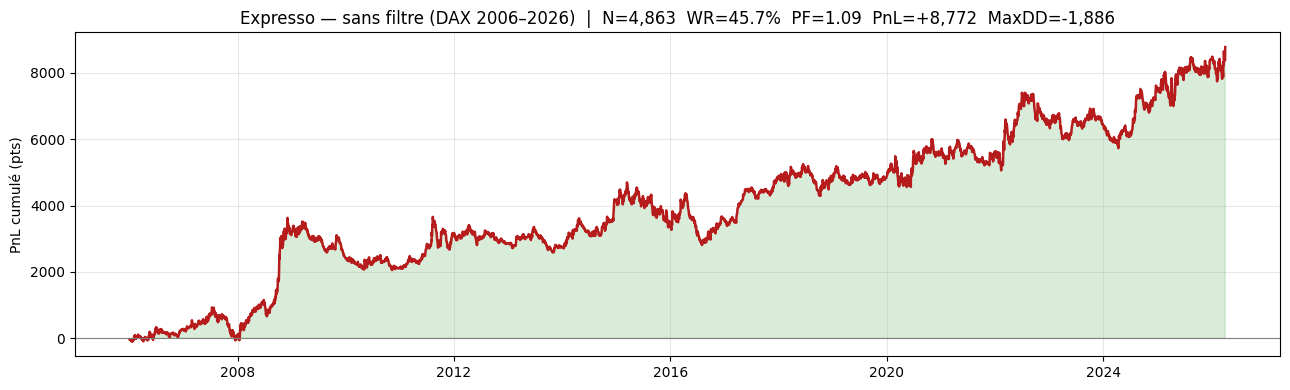

In [26]:
show_equity(exp_raw, 'Expresso — sans filtre (DAX 2006–2026)', color='#B71C1C')

---
## 3. PDH/PDL — Previous Day High / Low

**Signal** : High et Low de la journée précédente (session complète 09:00–17:35 CET).

**Logique** : Buy stop au-dessus du PDH+5 pts, sell stop en-dessous du PDL−5 pts. Stop loss = l'autre niveau. Sortie en fin de journée.

> Backtest **sans filtre** sur les données CSV 2006–2026 (analyse), puis sur les données Capital.com (résultats live).

In [27]:
BUFFER_PDH = 5
EOD_PDH    = '17:35'


def simulate_pdhl(day_bars, sig_high, sig_low, buffer=5):
    el = sig_high + buffer
    es = sig_low  - buffer
    if day_bars['open'].iloc[0] >= el or day_bars['open'].iloc[0] <= es:
        return None  # gap au-dela du niveau -> fill irrealiste
    direction = entry_price = entry_time = stop = None

    for ts, bar in day_bars.iterrows():
        if direction: break
        bh, bl = bar['high'], bar['low']
        if bh >= el and bl <= es:
            direction, entry_price, stop = ('long', el, es) if bar['open'] >= el else ('short', es, el)
        elif bh >= el:  direction, entry_price, stop = 'long',  el, es
        elif bl <= es:  direction, entry_price, stop = 'short', es, el
        if direction: entry_time = ts

    if not direction:
        return None

    exit_price = None
    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        if direction == 'long' and bar['low'] <= stop:  exit_price = stop; break
        if direction == 'short' and bar['high'] >= stop: exit_price = stop; break
    if exit_price is None:
        exit_price = day_bars[day_bars.index >= entry_time].iloc[-1]['close']

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)
    return {
        'direction':  direction,
        'entry':      round(entry_price, 1),
        'exit':       round(exit_price, 1),
        'stop':       round(stop, 1),
        'pnl':        round(pnl, 2),
    }


def run_pdhl(df_5min, no_friday=False, range_filter=False, skip_months=False):
    SKIP_M = {1, 7, 8}
    dates  = sorted(set(df_5min.index.date))
    trades = []
    for i, d in enumerate(dates):
        if i == 0: continue
        ts = pd.Timestamp(d)
        if no_friday   and ts.dayofweek == 4:  continue
        if skip_months and ts.month in SKIP_M: continue
        prev_b = df_5min.loc[str(dates[i - 1])]
        if len(prev_b) < 2: continue
        sh, sl = prev_b['high'].max(), prev_b['low'].min()
        if range_filter and not (50 <= sh - sl <= 300): continue
        day_b = df_5min.loc[str(d)]
        if len(day_b) < 2: continue
        r = simulate_pdhl(day_b, sh, sl, BUFFER_PDH)
        if r:
            r['sig_range'] = round(sh - sl, 1)
            r['date'] = ts
            trades.append(r)
    if not trades:
        return pd.DataFrame()
    return pd.DataFrame(trades).set_index('date').sort_index()

In [28]:
pdhl_raw = run_pdhl(raw)  # CSV 2006-2026, sans filtre
m = compute_metrics(pdhl_raw, 'PDH/PDL brut (sans filtre, CSV)')
print(pd.DataFrame([m]).set_index('label').to_string())

                                 n_trades  win_rate_%  avg_win  avg_loss  profit_factor  total_pnl  sharpe  max_dd
label                                                                                                             
PDH/PDL brut (sans filtre, CSV)      4582        50.5     87.2     -75.8           1.17    29842.0    0.88 -4609.0


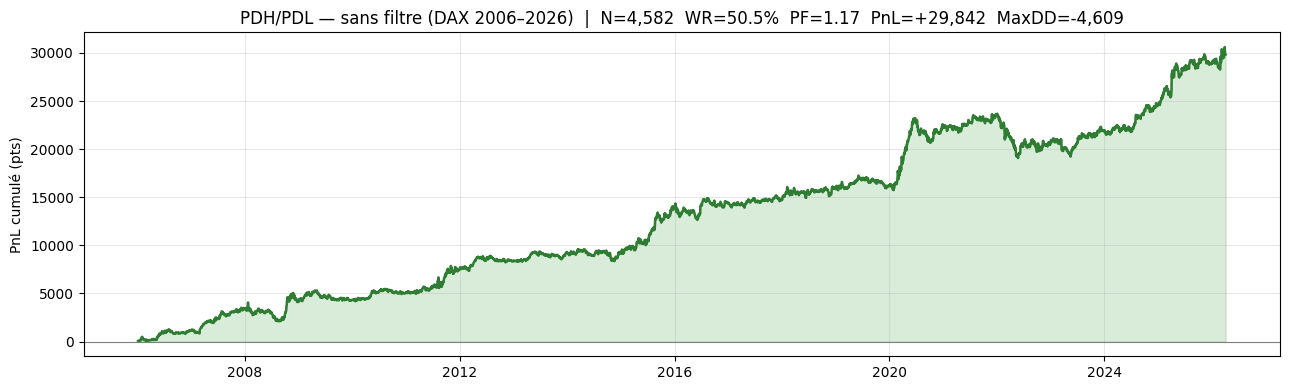

In [29]:
show_equity(pdhl_raw, 'PDH/PDL — sans filtre (DAX 2006–2026)', color='#2E7D32')

---
## Analyse descriptive — Pourquoi des filtres ?

Chaque stratégie est analysée **indépendamment** : on regarde le PnL par jour de semaine, par mois et par tranche de range signal **sur les données brutes**.
Les filtres retenus seront les conséquences directes de ces observations.

=== ASRS ===


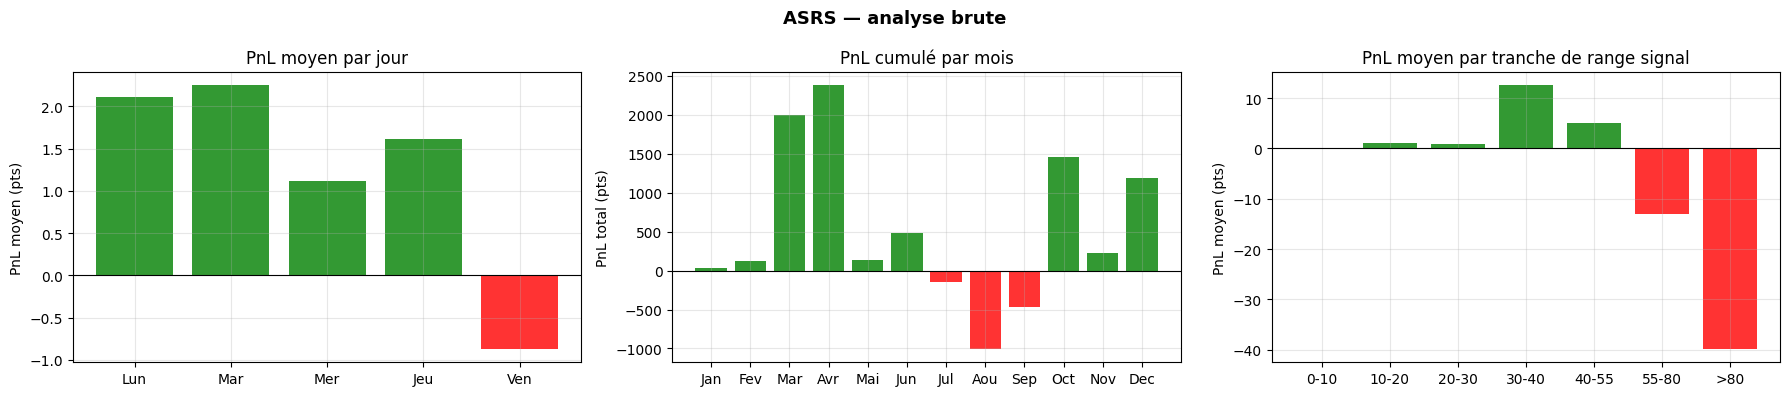

  Vendredi : PnL moyen -0.9 pts | total -885 pts
  Mois deficitaires : ['Jul', 'Aou', 'Sep']


In [30]:
dow_labels   = {0:'Lun', 1:'Mar', 2:'Mer', 3:'Jeu', 4:'Ven'}
month_labels = {1:'Jan',2:'Fev',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
                7:'Jul',8:'Aou',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}


def analyse_strategy(df, label, color, range_col='sig_range',
                     range_bins=None, range_lbl=None):
    df = df.copy()
    df['dow']   = df.index.dayofweek
    df['month'] = df.index.month
    df['dow_lbl']   = df['dow'].map(dow_labels)
    df['month_lbl'] = df['month'].map(month_labels)

    grp_dow = df.groupby('dow_lbl')['pnl'].agg(['mean', 'sum']).reindex(dow_labels.values())
    grp_m   = df.groupby('month_lbl')['pnl'].agg(['mean', 'sum']).reindex(month_labels.values())

    n_plots = 3 if (range_col in df.columns and range_bins) else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
    fig.suptitle(f'{label} — analyse brute', fontsize=13, fontweight='bold')

    # Day of week
    col_d = ['red' if v < 0 else 'green' for v in grp_dow['mean']]
    axes[0].bar(grp_dow.index, grp_dow['mean'], color=col_d, alpha=0.8)
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].set_title('PnL moyen par jour')
    axes[0].set_ylabel('PnL moyen (pts)')
    axes[0].grid(True, alpha=0.3)

    # Month
    col_m = ['red' if v < 0 else 'green' for v in grp_m['sum']]
    axes[1].bar(grp_m.index, grp_m['sum'], color=col_m, alpha=0.8)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('PnL cumulé par mois')
    axes[1].set_ylabel('PnL total (pts)')
    axes[1].grid(True, alpha=0.3)

    # Range distribution
    if n_plots == 3:
        grp_r = df.groupby(pd.cut(df[range_col], bins=range_bins, labels=range_lbl),
                           observed=True)['pnl'].mean()
        col_r = ['red' if v < 0 else 'green' for v in grp_r]
        axes[2].bar(grp_r.index.astype(str), grp_r.values, color=col_r, alpha=0.8)
        axes[2].axhline(0, color='black', lw=0.8)
        axes[2].set_title('PnL moyen par tranche de range signal')
        axes[2].set_ylabel('PnL moyen (pts)')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print worst days / months
    fri = grp_dow.loc['Ven'] if 'Ven' in grp_dow.index else None
    if fri is not None:
        print(f'  Vendredi : PnL moyen {fri["mean"]:+.1f} pts | total {fri["sum"]:+.0f} pts')
    bad_m = grp_m[grp_m['sum'] < 0].index.tolist()
    print(f'  Mois deficitaires : {bad_m}')


print('=== ASRS ===')
analyse_strategy(
    asrs_raw, 'ASRS', '#1565C0',
    range_bins=[0, 10, 20, 30, 40, 55, 80, 999],
    range_lbl=['0-10','10-20','20-30','30-40','40-55','55-80','>80'],
)

=== Expresso ===


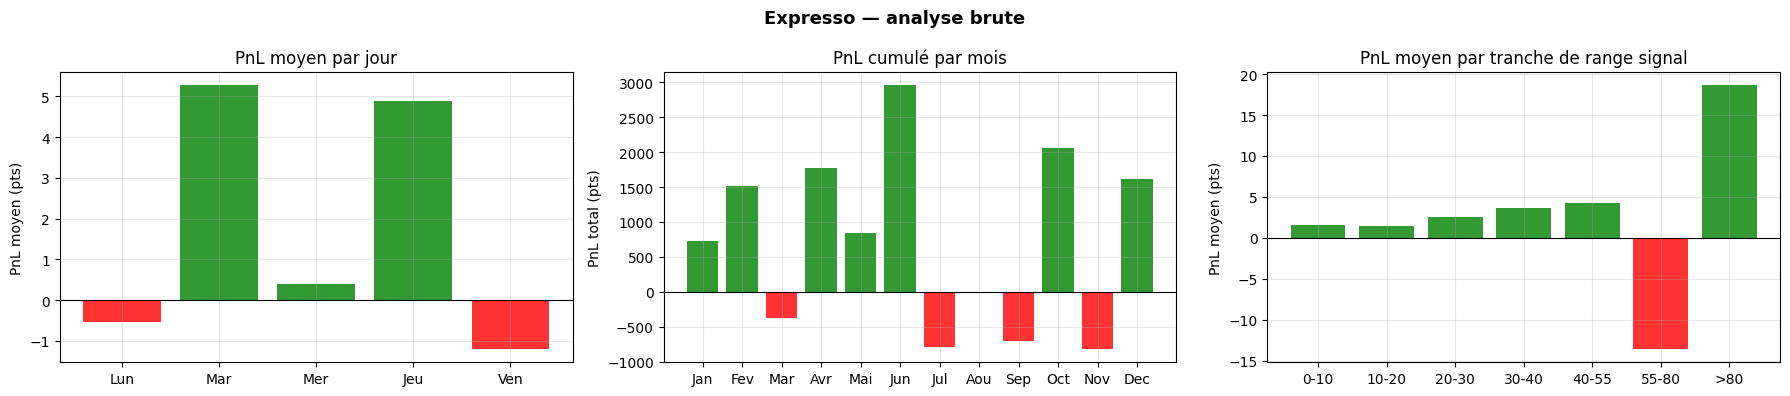

  Vendredi : PnL moyen -1.2 pts | total -1163 pts
  Mois deficitaires : ['Mar', 'Jul', 'Aou', 'Sep', 'Nov']


In [31]:
print('=== Expresso ===')
analyse_strategy(
    exp_raw, 'Expresso', '#B71C1C',
    range_bins=[0, 10, 20, 30, 40, 55, 80, 999],
    range_lbl=['0-10','10-20','20-30','30-40','40-55','55-80','>80'],
)

=== PDH/PDL ===


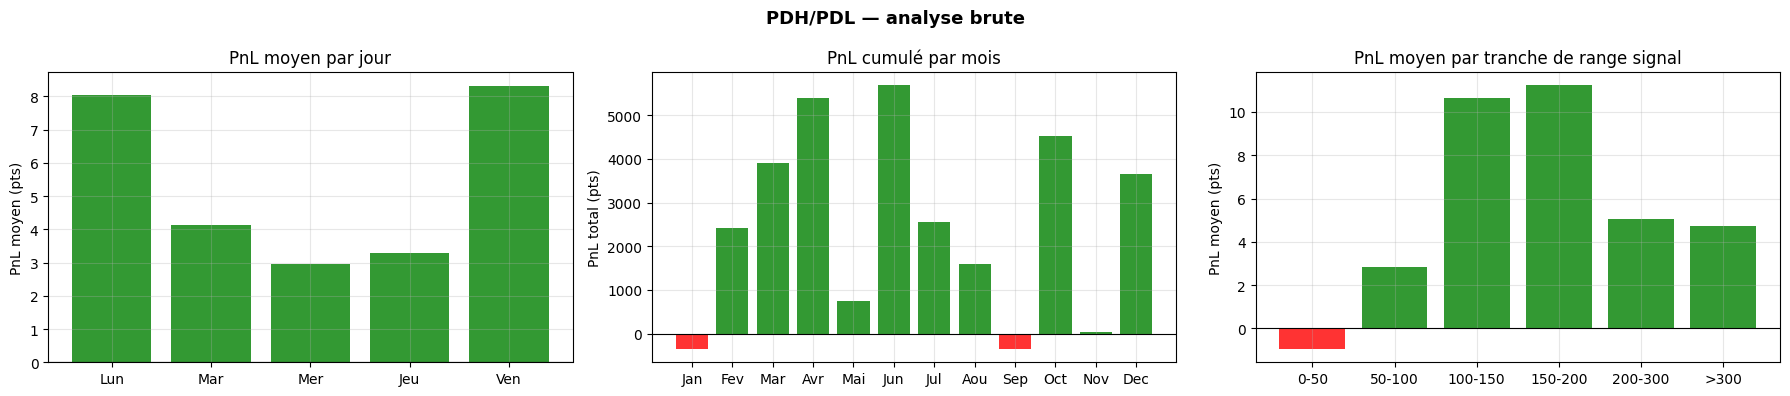

  Vendredi : PnL moyen +8.3 pts | total +6922 pts
  Mois deficitaires : ['Jan', 'Sep']


In [32]:
print('=== PDH/PDL ===')
analyse_strategy(
    pdhl_raw, 'PDH/PDL', '#2E7D32',
    range_col='sig_range',
    range_bins=[0, 50, 100, 150, 200, 300, 9999],
    range_lbl=['0-50','50-100','100-150','150-200','200-300','>300'],
)

---
## Synthèse : filtres comme conséquences

| Filtre | Observation | Règle |
|--------|-------------|-------|
| **F1 — Vendredi** | PnL moyen négatif le vendredi dans les 3 stratégies | Exclure le vendredi |
| **F2 — Range signal** | Ranges <10 pts (faible vol) et >55 pts (gap/choc) dégradent le PnL | Garder 10–55 pts (ASRS, Expresso) · 50–300 pts (PDH/PDL) |
| **F3 — Mois** | Janvier, juillet, août systématiquement déficitaires | Exclure jan, juil, août |

> Les filtres sont appliqués progressivement dans la section suivante.

---
## Application des filtres

Pour chaque stratégie on compare le résultat **brut** vs **filtré** (F1+F2+F3).

=== ASRS ===
                        n_trades  win_rate_%  avg_win  avg_loss  profit_factor  total_pnl  sharpe  max_dd
label                                                                                                    
ASRS brut                   5136        28.3     55.2     -20.0           1.09     6405.0    0.42 -2638.0
ASRS filtré (F1+F2+F3)      2134        30.2     67.2     -22.9           1.27     9278.0    1.23 -1112.0


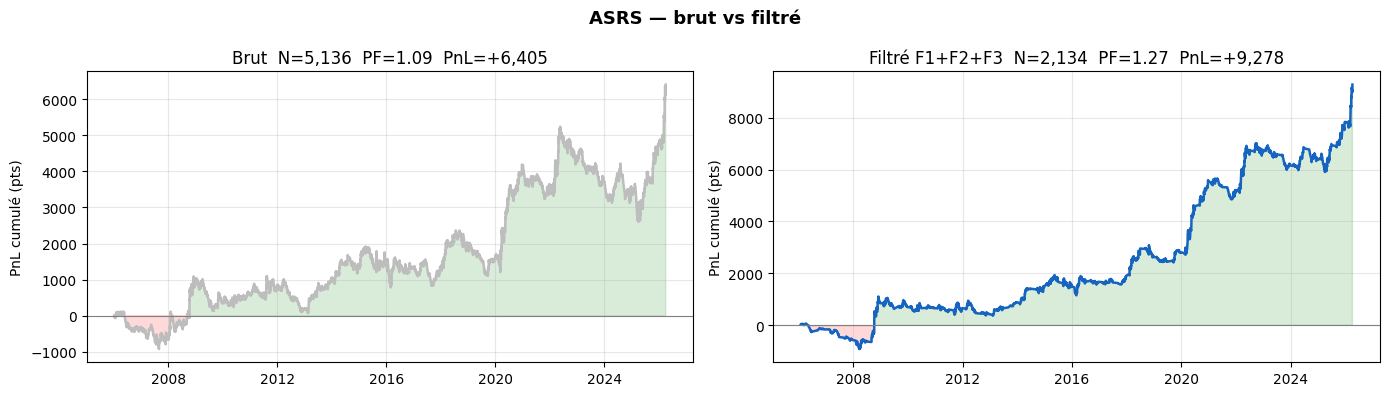

In [33]:
asrs_filt = run_asrs(no_friday=True, range_filter=True, skip_months=True)

rows = [
    compute_metrics(asrs_raw,  'ASRS brut'),
    compute_metrics(asrs_filt, 'ASRS filtré (F1+F2+F3)'),
]
print('=== ASRS ===')
print(pd.DataFrame(rows).set_index('label').to_string())

# Equity curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('ASRS — brut vs filtré', fontsize=13, fontweight='bold')
for ax, df, lbl, col in [
    (axes[0], asrs_raw,  'Brut',        '#BDBDBD'),
    (axes[1], asrs_filt, 'Filtré F1+F2+F3', '#1565C0'),
]:
    cum = df['pnl'].cumsum()
    ax.fill_between(cum.index, cum.values, 0, where=cum.values >= 0, alpha=0.15, color='green')
    ax.fill_between(cum.index, cum.values, 0, where=cum.values  < 0, alpha=0.15, color='red')
    ax.plot(cum.index, cum.values, color=col, lw=1.8)
    ax.axhline(0, color='gray', lw=0.8)
    m = compute_metrics(df)
    ax.set_title(f"{lbl}  N={m['n_trades']:,}  PF={m['profit_factor']}  PnL={m['total_pnl']:+,.0f}")
    ax.set_ylabel('PnL cumulé (pts)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Expresso ===
                            n_trades  win_rate_%  avg_win  avg_loss  profit_factor  total_pnl  sharpe  max_dd
label                                                                                                        
Expresso brut                   4863        45.7     48.7     -37.7           1.09     8772.0    0.49 -1886.0
Expresso filtré (F1+F2+F3)      2074        46.6     57.8     -41.5           1.21     9832.0    1.15 -1258.0


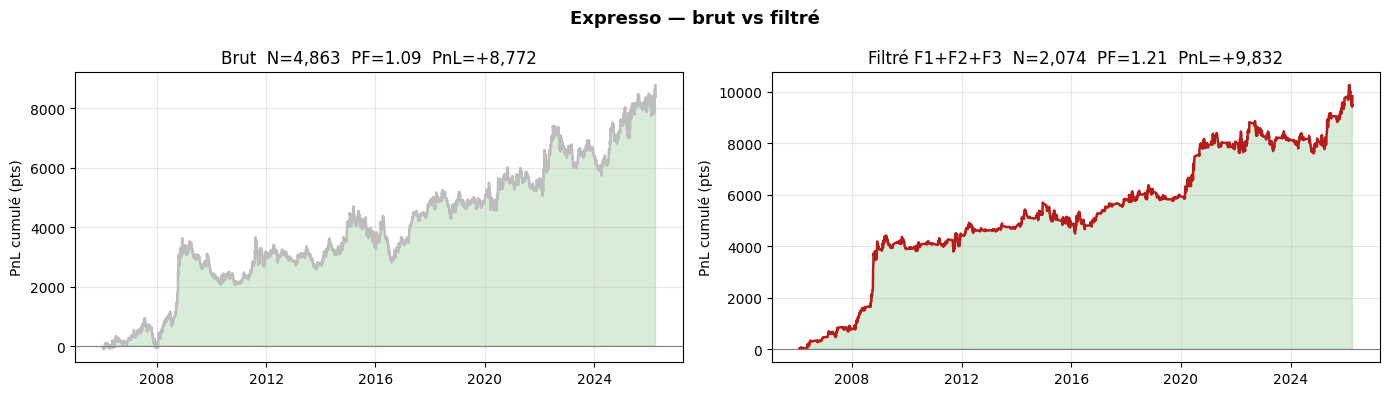

In [34]:
exp_filt = run_expresso(no_friday=True, range_filter=True, skip_months=True)

rows = [
    compute_metrics(exp_raw,  'Expresso brut'),
    compute_metrics(exp_filt, 'Expresso filtré (F1+F2+F3)'),
]
print('=== Expresso ===')
print(pd.DataFrame(rows).set_index('label').to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Expresso — brut vs filtré', fontsize=13, fontweight='bold')
for ax, df, lbl, col in [
    (axes[0], exp_raw,  'Brut',            '#BDBDBD'),
    (axes[1], exp_filt, 'Filtré F1+F2+F3', '#B71C1C'),
]:
    cum = df['pnl'].cumsum()
    ax.fill_between(cum.index, cum.values, 0, where=cum.values >= 0, alpha=0.15, color='green')
    ax.fill_between(cum.index, cum.values, 0, where=cum.values  < 0, alpha=0.15, color='red')
    ax.plot(cum.index, cum.values, color=col, lw=1.8)
    ax.axhline(0, color='gray', lw=0.8)
    m = compute_metrics(df)
    ax.set_title(f"{lbl}  N={m['n_trades']:,}  PF={m['profit_factor']}  PnL={m['total_pnl']:+,.0f}")
    ax.set_ylabel('PnL cumulé (pts)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== PDH/PDL ===
                             n_trades  win_rate_%  avg_win  avg_loss  profit_factor  total_pnl  sharpe  max_dd
label                                                                                                         
PDH/PDL brut (CSV)               4582        50.5     87.2     -75.8           1.17    29842.0    0.88 -4609.0
PDH/PDL filtré (CSV)             2298        51.3     83.5     -71.0           1.24    18893.0    1.23 -1615.0
PDH/PDL filtré (live ~1 an)       101        54.5    131.4    -114.8           1.37     1944.0    1.82  -930.0


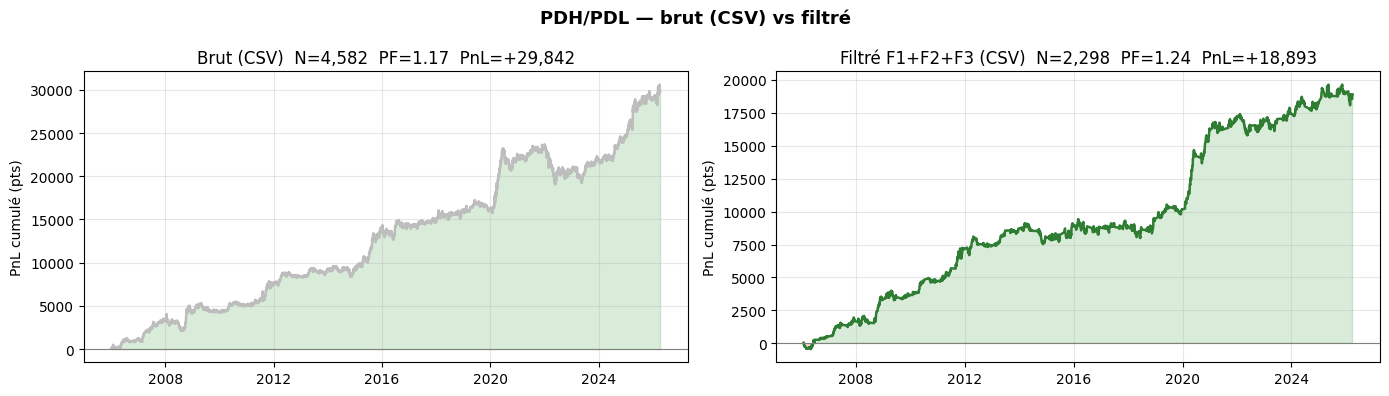

In [35]:
pdhl_filt_csv = run_pdhl(raw, no_friday=True, range_filter=True, skip_months=True)

rows = [
    compute_metrics(pdhl_raw,      'PDH/PDL brut (CSV)'),
    compute_metrics(pdhl_filt_csv, 'PDH/PDL filtré (CSV)'),
]
print('=== PDH/PDL ===')
print(pd.DataFrame(rows).set_index('label').to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('PDH/PDL — brut vs filtré (CSV 2006-2026)', fontsize=13, fontweight='bold')
for ax, df, lbl, col in [
    (axes[0], pdhl_raw,      'Brut',             '#BDBDBD'),
    (axes[1], pdhl_filt_csv, 'Filtré F1+F2+F3',  '#2E7D32'),
]:
    cum = df['pnl'].cumsum()
    ax.fill_between(cum.index, cum.values, 0, where=cum.values >= 0, alpha=0.15, color='green')
    ax.fill_between(cum.index, cum.values, 0, where=cum.values  < 0, alpha=0.15, color='red')
    ax.plot(cum.index, cum.values, color=col, lw=1.8)
    ax.axhline(0, color='gray', lw=0.8)
    m = compute_metrics(df)
    ax.set_title(f"{lbl}  N={m['n_trades']:,}  PF={m['profit_factor']}  PnL={m['total_pnl']:+,.0f}")
    ax.set_ylabel('PnL cumulé (pts)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Comparaison finale des 3 stratégies filtrées

> ASRS et Expresso : données CSV 2006–2026.  
> PDH/PDL : données Capital.com (~1 an) — seule source intraday disponible pour ce signal.

=== Résultats finaux ===
                              n_trades  win_rate_%  profit_factor  total_pnl  max_dd
label                                                                               
ASRS filtré (CSV 20 ans)          2134        30.2           1.27     9278.0 -1112.0
Expresso filtré (CSV 20 ans)      2074        46.6           1.21     9832.0 -1258.0
PDH/PDL filtré (live ~1 an)        101        54.5           1.37     1944.0  -930.0


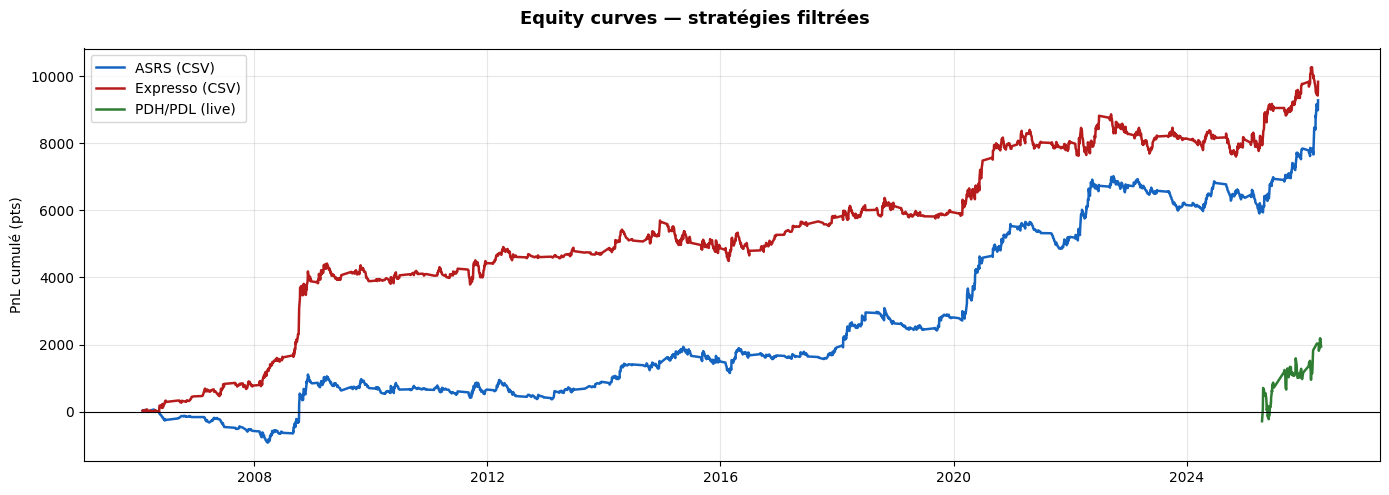

In [36]:
summary = pd.DataFrame([
    compute_metrics(asrs_filt,     'ASRS filtré (CSV 20 ans)'),
    compute_metrics(exp_filt,      'Expresso filtré (CSV 20 ans)'),
    compute_metrics(pdhl_filt_csv, 'PDH/PDL filtré (CSV 20 ans)'),
]).set_index('label')

print('=== Résultats finaux (CSV 2006-2026) ===')
print(summary[['n_trades','win_rate_%','profit_factor','total_pnl','max_dd']].to_string())

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Equity curves — stratégies filtrées (CSV 2006-2026)', fontsize=13, fontweight='bold')
for df, lbl, col in [
    (asrs_filt,     'ASRS',     '#1565C0'),
    (exp_filt,      'Expresso', '#B71C1C'),
    (pdhl_filt_csv, 'PDH/PDL',  '#2E7D32'),
]:
    cum = df['pnl'].cumsum()
    ax.plot(cum.index, cum.values, lw=1.8, label=lbl, color=col)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('PnL cumulé (pts)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()